In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("titanic_sample.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,S


In [3]:
# Shape (rows, columns)
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns)

# Data types & null values
df.info()

# Statistical summary
df.describe()

Shape: (10, 8)
Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Fare',
       'Embarked'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  10 non-null     int64  
 1   Survived     10 non-null     int64  
 2   Pclass       10 non-null     int64  
 3   Name         10 non-null     object 
 4   Sex          10 non-null     object 
 5   Age          9 non-null      float64
 6   Fare         10 non-null     float64
 7   Embarked     10 non-null     object 
dtypes: float64(2), int64(3), object(3)
memory usage: 772.0+ bytes


,PassengerId,Survived,Pclass,Age,Fare
count,10.00000,10.000000,10.000000,9.000000,10.000000
mean,5.50000,0.500000,2.300000,28.111111,27.020820
std,3.02765,0.527046,0.948683,14.945271,23.601938
min,1.00000,0.000000,1.000000,2.000000,7.250000
25%,3.25000,0.000000,1.250000,22.000000,8.152075
50%,5.50000,0.500000,3.000000,27.000000,16.104150
75%,7.75000,1.000000,3.000000,35.000000,46.414575
max,10.00000,1.000000,3.000000,54.000000,71.283300


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,1
Fare,0
Embarked,0


In [5]:
# Fill Age with mean
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Fill Embarked with most frequent value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Verify again
df.isnull().sum()

/tmp/ipykernel_372/1646541831.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_372/1646541831.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
Fare,0
Embarked,0


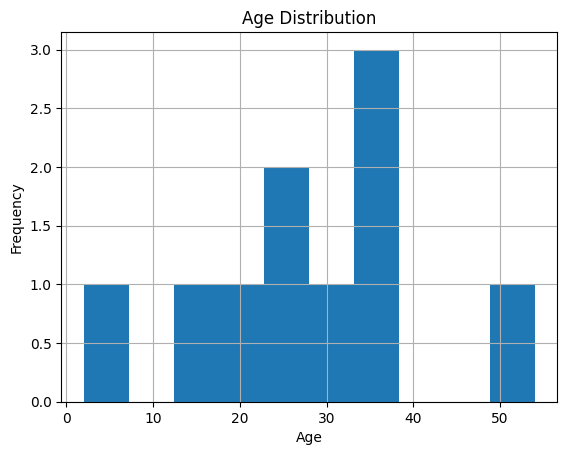

In [6]:
plt.figure()
df['Age'].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

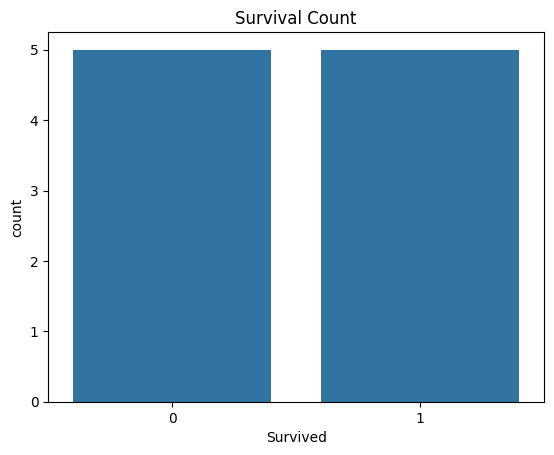

In [7]:
plt.figure()
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

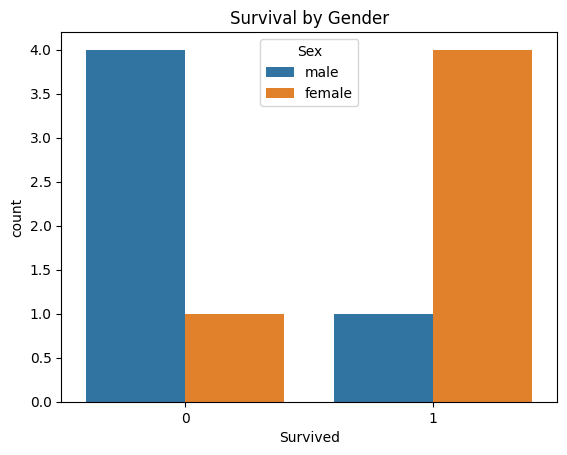

In [8]:
plt.figure()
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender")
plt.show()

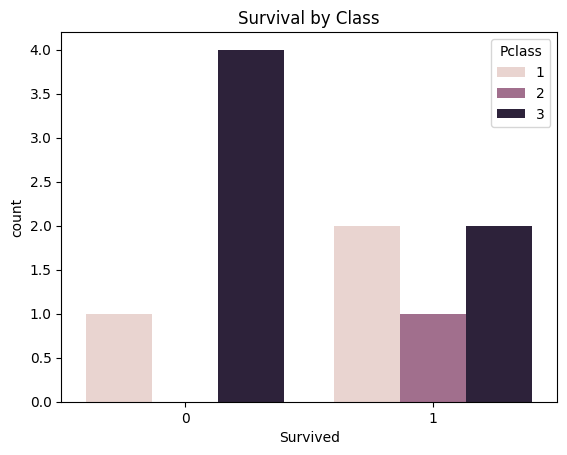

In [9]:
plt.figure()
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title("Survival by Class")
plt.show()

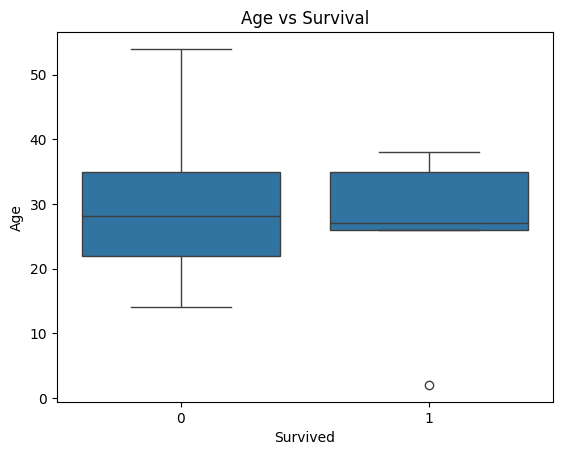

In [10]:
plt.figure()
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

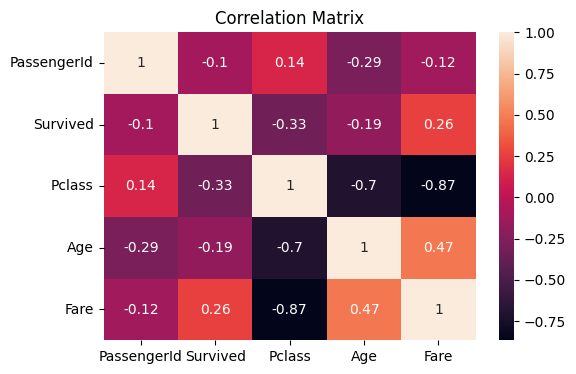

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [12]:
# Average age of survivors vs non-survivors
print(df.groupby('Survived')['Age'].mean())

# Survival rate by gender
print(df.groupby('Sex')['Survived'].mean())

# Survival rate by class
print(df.groupby('Pclass')['Survived'].mean())

Survived
0    30.622222
1    25.600000
Name: Age, dtype: float64
Sex
female    0.8
male      0.2
Name: Survived, dtype: float64
Pclass
1    0.666667
2    1.000000
3    0.333333
Name: Survived, dtype: float64
